# Advanced River Temperature Dynamics: Full Energy Budget and Dynamic Forcing

## Overview

This tutorial builds upon the basic advection-dispersion example to showcase the full thermodynamic capabilities of the `RiverTemperatureDynamics` component. 

In shallow mountain streams, the water temperature is highly sensitive to diurnal atmospheric changes, but it is heavily buffered by the surrounding environment. In this notebook, we will simulate a full 24-hour cycle by introducing:
1. **Dynamic Meteorological Forcing**: Passing a `.csv` time-series to automatically update air temperature, solar radiation, wind, and cloud cover at every time step.
2. **Bed Heat Conduction**: Simulating the thermal inertia of the active sediment layer beneath the river.
3. **Hyporheic/Groundwater Exchange**: Introducing a continuous upwelling of cold groundwater into the channel.

Let's import the necessary libraries.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from landlab import RasterModelGrid
from landlab.components import RiverTemperatureDynamics

### 1. Generate Dynamic Meteorological Forcing
Instead of manually updating grid fields every time step, the component can interpolate time-series data from a CSV. 

Here, we create a synthetic 24-hour meteorological dataset. Notice how solar radiation peaks at noon, air temperature peaks around 2:00 PM, and cloud cover rolls in during the late afternoon.

In [2]:
# Create 24 hours of data (1-hour intervals)
times = np.arange(0, 86400 + 3600, 3600)

# Synthetic diurnal patterns
T_air = 15.0 + 10.0 * np.sin(np.pi * (times - 8 * 3600) / (12 * 3600))  # Peaks at 25 C at 14:00
Q_sw = np.zeros_like(times)
daylight = (times >= 6 * 3600) & (times <= 18 * 3600)
Q_sw[daylight] = 800.0 * np.sin(np.pi * (times[daylight] - 6 * 3600) / (12 * 3600))  # Peaks at 800 W/m2 at noon
cloud_cover = np.linspace(0.0, 0.6, len(times))  # Clear morning, cloudy evening

df_met = pd.DataFrame({
    "time_sec": times,
    "T_air": T_air,
    "RH": np.full_like(times, 40.0),       # Constant 40% humidity
    "u_wind": np.full_like(times, 1.5),    # Constant 1.5 m/s breeze
    "Q_sw": Q_sw,
    "cloud_cover": cloud_cover
})

# Save to CSV for the component to read
met_filename = "synthetic_diurnal_met.csv"
df_met.to_csv(met_filename, index=False)
df_met.head()

,time_sec,T_air,RH,u_wind,Q_sw,cloud_cover
0,0,6.339746,40,1,0,0.000
1,3600,5.340742,40,1,0,0.025
2,7200,5.000000,40,1,0,0.050
3,10800,5.340742,40,1,0,0.075
4,14400,6.339746,40,1,0,0.100


### 2. Grid and Hydrodynamic Setup
For a 24-hour thermal simulation, we prescribe steady-state flow fields. This allows us to focus entirely on the thermal physics and bypasses the computational overhead and numerical instability risks of spinning up a high-resolution hydrodynamic solver.

In [3]:
# Grid and Channel Parameters
dx = 2.0
nrows = 13
ncols = 101
channel_slope = 0.002
h_normal = 0.4
v_normal = 0.6  # Prescribed steady velocity (~0.6 m/s)

grid = RasterModelGrid((nrows, ncols), xy_spacing=dx)

# Topography and masks
te = grid.add_field("topographic__elevation", (dx * (ncols - 1) - grid.x_of_node) * channel_slope, at="node", clobber=True)
bank_mask = (grid.y_of_node < dx) | (grid.y_of_node > dx * (nrows - 2))
channel_mask = ~bank_mask
te[bank_mask] = 5.0

# Prescribe static hydrodynamics
h = grid.add_zeros("surface_water__depth", at="node", clobber=True)
h[channel_mask] = h_normal

vel = grid.add_zeros("surface_water__velocity", at="link", clobber=True)
horiz_links = grid.horizontal_links
link_y = grid.y_of_node[grid.node_at_link_tail[horiz_links]]
channel_hlinks = horiz_links[(link_y >= dx) & (link_y <= dx * (nrows - 2))]
vel[channel_hlinks] = v_normal

### 3. Initialize Thermal Fields and Advanced Physics
We define the initial water temperature, as well as the fields for the sediment bed and groundwater. Note that Landlab requires atmospheric fields to exist on the grid prior to initialization, even though our `.csv` file will immediately overwrite them with data.

In [4]:
# Water and Bed Temperature Initial Conditions
T_w = grid.add_zeros("surface_water__temperature", at="node", clobber=True)
T_w[:] = 12.0  # Start with cool morning water

T_bed = grid.add_zeros("sediment__temperature", at="node", clobber=True)
T_bed[:] = 14.0  # Bed retained some heat from yesterday

# Groundwater / Hyporheic Exchange
T_gw = grid.add_zeros("groundwater__temperature", at="node", clobber=True)
T_gw[:] = 10.0  # Cold groundwater

q_gw = grid.add_zeros("groundwater__specific_discharge", at="node", clobber=True)
q_gw[channel_mask] = 2.0e-5  # Constant upwelling into the channel

# Advection velocity and static sun angle
adv_vel = grid.add_zeros("advection__velocity", at="link", clobber=True)
adv_vel[:] = vel[:]
grid.add_zeros("solar__altitude_angle", at="node", clobber=True)[:] = np.radians(50.0)

# Atmospheric fields required for component initialization
for field in ["air__temperature", "air__relative_humidity", "air__velocity", 
              "radiation__incoming_shortwave_flux", "cloud_cover__fraction"]:
    grid.add_zeros(field, at="node", clobber=True)

# Create the component
rtd = RiverTemperatureDynamics(
    grid,
    met_file=met_filename,  # Automatically reads and interpolates our CSV!
    shade_factor=0.2,       # 20% riparian shading
    k_bed=1.5,              # Thermal conductivity of gravel/cobble bed
    dz_bed=0.5,             # 50 cm active sediment layer
)

### 4. Run the 24-Hour Simulation
We use a time step of `dt = 0.5 s` to strictly satisfy the Courant-Friedrichs-Lewy (CFL) stability condition for the advection scheme.

We also introduce a **dynamic boundary condition** at the inlet: the water arriving from upstream fluctuates slightly with the air temperature, simulating the warming of the river as it travels miles down the watershed before reaching our study reach.

In [5]:
dt_temp = 0.5  
n_steps = int(86400 / dt_temp)
center_node = grid.core_nodes[len(grid.core_nodes) // 2]

# Entry nodes for boundary condition
channel_rows = np.arange(1, nrows - 1)
fixed_entry_nodes = channel_rows * ncols

# Dictionaries to store time-series data for plotting
history = {
    "time_hr": [], "T_water": [], "T_bed": [], "T_air": [],
    "Q_sw_net": [], "Q_lw_in": [], "Q_lw_out": [], 
    "Q_evap": [], "Q_conv": [], "Q_bed": [], "Q_gw": [], "Q_net": []
}

print(f"Running 24-hour thermal simulation ({n_steps} steps)...")
for step in range(n_steps):
    t_sim = step * dt_temp
    
    # Pass t_sim so the component knows to update meteorological fields
    rtd.run_one_step(dt_temp, t_sim=t_sim)
    
    # Dynamic Boundary Condition (Simulate upstream river heating)
    current_air = grid.at_node["air__temperature"][center_node]
    upstream_T = 12.0 + 0.3 * (current_air - 15.0) 
    
    T_w[fixed_entry_nodes] = upstream_T
    T_w[bank_mask] = upstream_T
    
    # Record data every 15 minutes (900 seconds)
    if t_sim % 900 == 0:
        history["time_hr"].append(t_sim / 3600.0)
        history["T_water"].append(T_w[center_node])
        history["T_bed"].append(T_bed[center_node])
        history["T_air"].append(grid.at_node["air__temperature"][center_node])
        history["Q_sw_net"].append(rtd.Q_sw_net[center_node])
        history["Q_lw_in"].append(rtd.Q_lw_in[center_node])
        history["Q_lw_out"].append(rtd.Q_lw_out[center_node])
        history["Q_evap"].append(rtd.Q_evap[center_node])
        history["Q_conv"].append(rtd.Q_conv[center_node])
        history["Q_bed"].append(rtd.Q_bed[center_node])
        history["Q_gw"].append(rtd.Q_gw[center_node])
        history["Q_net"].append(rtd.Q_net[center_node])

print("Simulation complete!")

Running 24-hour thermal simulation (172800 steps)...
Simulation complete!


### 5. Visualizing the Diurnal Cycle
First, let's look at the thermal buffering. The large plot shows the full system, while the smaller, auto-scaled plot isolates the water temperature to reveal the fine thermal dynamics occurring inside the channel.

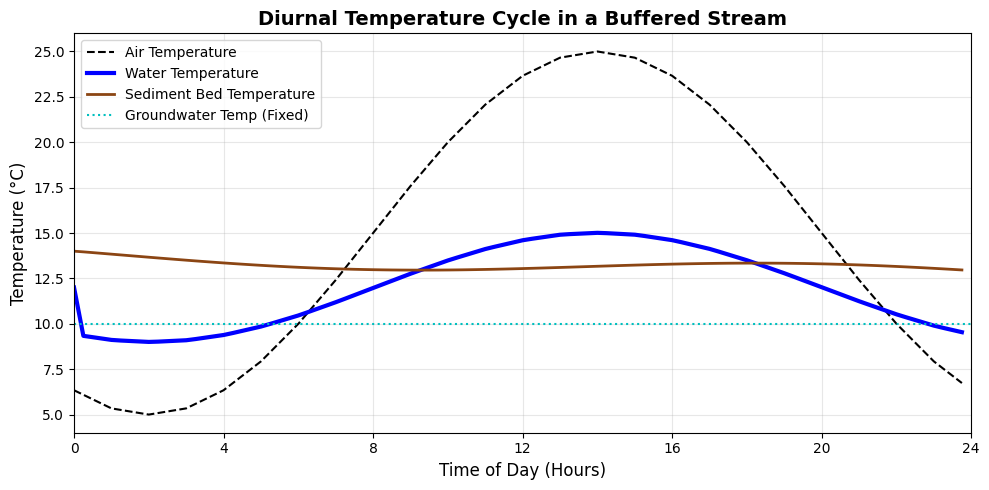

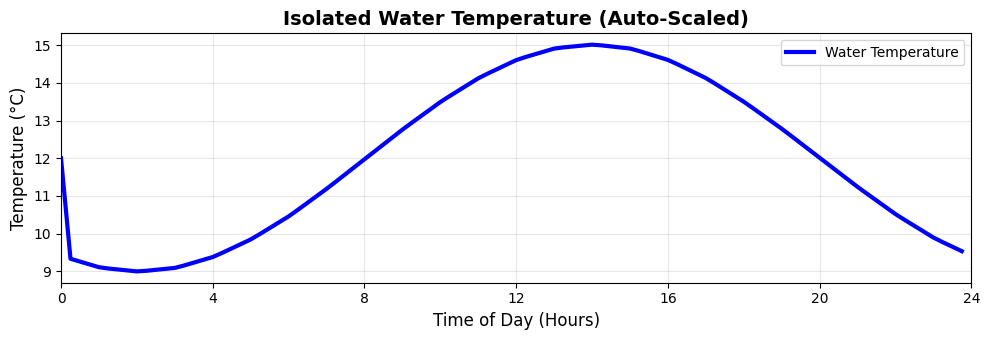

In [6]:
# 1. Main Plot: Full System Overview
plt.figure(figsize=(10, 5))
plt.plot(history["time_hr"], history["T_air"], 'k--', label='Air Temperature')
plt.plot(history["time_hr"], history["T_water"], 'b-', lw=3, label='Water Temperature')
plt.plot(history["time_hr"], history["T_bed"], 'saddlebrown', lw=2, label='Sediment Bed Temperature')
plt.axhline(10.0, color='c', linestyle=':', label='Groundwater Temp (Fixed)')

plt.title("Diurnal Temperature Cycle in a Buffered Stream", fontsize=14, fontweight="bold")
plt.xlabel("Time of Day (Hours)", fontsize=12)
plt.ylabel("Temperature (°C)", fontsize=12)
plt.xlim(0, 24)
plt.xticks(np.arange(0, 25, 4))
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 2. Zoomed Plot: Isolated Water Temperature
plt.figure(figsize=(10, 3.5))
plt.plot(history["time_hr"], history["T_water"], 'b-', lw=3, label='Water Temperature')

plt.title("Isolated Water Temperature (Auto-Scaled)", fontsize=14, fontweight="bold")
plt.xlabel("Time of Day (Hours)", fontsize=12)
plt.ylabel("Temperature (°C)", fontsize=12)
plt.xlim(0, 24)
plt.xticks(np.arange(0, 25, 4))

# Auto-scale with a safety buffer to prevent numerical noise from looking like spikes
y_min, y_max = plt.ylim()
if (y_max - y_min) < 0.5:
    plt.ylim(y_min - 0.25, y_max + 0.25)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Next, we can plot the individual components of the energy budget to see exactly what is driving these temperature changes. 

* Positive values = Heat entering the water.
* Negative values = Heat leaving the water.

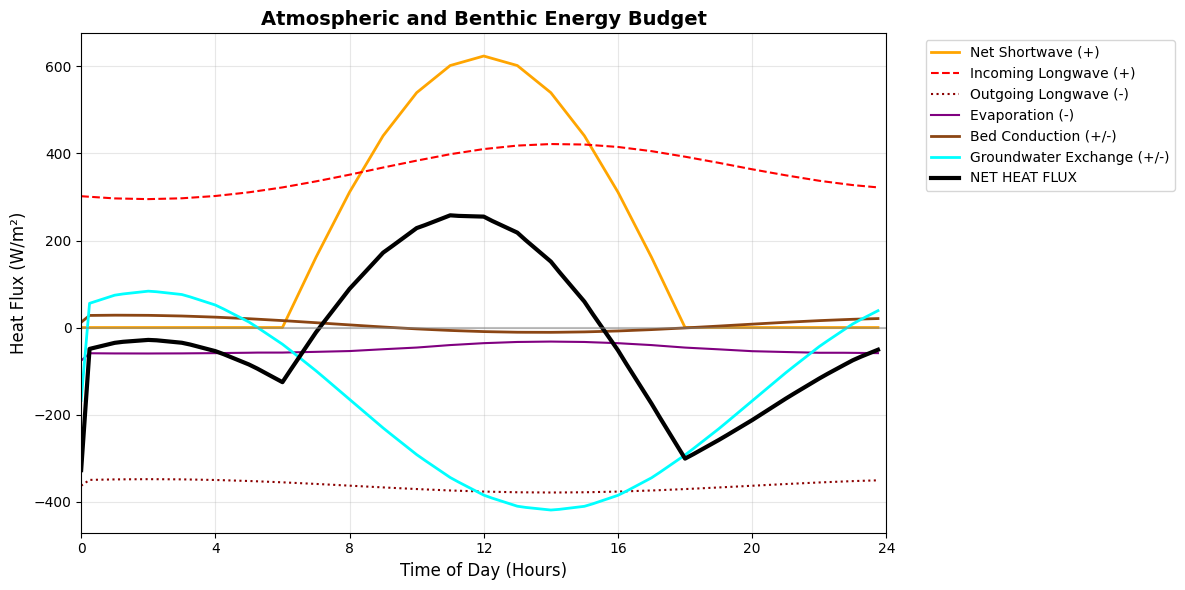

In [7]:
plt.figure(figsize=(12, 6))

# Plot the major fluxes
plt.plot(history["time_hr"], history["Q_sw_net"], color='orange', lw=2, label='Net Shortwave (+)')
plt.plot(history["time_hr"], history["Q_lw_in"], color='red', ls='--', label='Incoming Longwave (+)')
plt.plot(history["time_hr"], [-x for x in history["Q_lw_out"]], color='darkred', ls=':', label='Outgoing Longwave (-)')
plt.plot(history["time_hr"], [-x for x in history["Q_evap"]], color='purple', label='Evaporation (-)')
plt.plot(history["time_hr"], history["Q_bed"], color='saddlebrown', lw=2, label='Bed Conduction (+/-)')
plt.plot(history["time_hr"], history["Q_gw"], color='cyan', lw=2, label='Groundwater Exchange (+/-)')

# Plot the net balance
plt.plot(history["time_hr"], history["Q_net"], color='black', lw=3, label='NET HEAT FLUX')

plt.axhline(0, color='gray', alpha=0.5)
plt.title("Atmospheric and Benthic Energy Budget", fontsize=14, fontweight="bold")
plt.xlabel("Time of Day (Hours)", fontsize=12)
plt.ylabel("Heat Flux (W/m²)", fontsize=12)
plt.xlim(0, 24)
plt.xticks(np.arange(0, 25, 4))

# Place legend outside the plot
plt.legend(bbox_to_anchor=(1.04, 1), loc="upper left")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()